In [49]:
import pandas as pd, numpy as np, glob, os
import matplotlib.pyplot as plt

ROOT = "../compare_oct_cp0_gower_v2/"
sum_path = os.path.join(ROOT, "tree_inspection_summary.csv")
df = pd.read_csv(sum_path)

# Identify metrics columns your script wrote
metrics = ["auc","pr_auc","best_mcc","balanced_recall_gmean","balanced_specificity_gmean","optimal_f1"]
# Build paired deltas: pruned - unpruned for each dataset/seed
for m in metrics:
    df[f"delta_{m}"] = df[f"pr_{m}"] - df[f"un_{m}"]

df[["tag","seed"] + [f"un_{m}" for m in metrics] + [f"pr_{m}" for m in metrics] + [f"delta_{m}" for m in metrics]]

,tag,seed,un_auc,un_pr_auc,un_best_mcc,un_balanced_recall_gmean,un_balanced_specificity_gmean,un_optimal_f1,pr_auc,pr_pr_auc,pr_best_mcc,pr_balanced_recall_gmean,pr_balanced_specificity_gmean,pr_optimal_f1,delta_auc,delta_pr_auc,delta_best_mcc,delta_balanced_recall_gmean,delta_balanced_specificity_gmean,delta_optimal_f1
0,exp3_mix,100,0.560870,0.038296,0.085906,0.516484,0.657814,0.101911,0.570900,0.039607,0.085776,0.482143,0.712851,0.103599,0.010029,0.001311,-0.00013,-0.034341,0.055037,0.001688
1,exp4_matched_plus_random,100,0.765436,0.075221,0.162394,0.725275,0.711416,0.163279,0.765436,0.075221,0.162394,0.725275,0.711416,0.163279,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
2,exp3_mix,101,0.607301,0.049953,0.109600,0.483516,0.715396,0.122794,0.607301,0.049953,0.109600,0.483516,0.715396,0.122794,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
3,exp4_matched_plus_random,101,0.756771,0.078261,0.161765,0.559066,0.820677,0.166724,0.756771,0.078261,0.161765,0.559066,0.820677,0.166724,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
4,exp3_mix,102,0.576345,0.051310,0.113917,0.505495,0.706002,0.120748,0.576345,0.051310,0.113917,0.505495,0.706002,0.120748,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
5,exp4_matched_plus_random,102,0.738524,0.064607,0.159070,0.671703,0.688541,0.152108,0.738524,0.064607,0.159070,0.671703,0.688541,0.152108,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
6,exp3_mix,103,0.508723,0.047259,0.087583,0.276099,0.899104,0.097463,0.508723,0.047259,0.087583,0.276099,0.899104,0.097463,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
7,exp4_matched_plus_random,103,0.764964,0.069849,0.162931,0.619505,0.776199,0.158833,0.764964,0.069849,0.162931,0.619505,0.776199,0.158833,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000


In [50]:
#Plot: Exp3 vs Exp4 for the same pruning setting
wide = df.pivot(index="seed", columns="tag", values=[f"un_pr_auc", f"pr_pr_auc"])
# Flatten
wide.columns = [f"{a}_{b}" for a,b in wide.columns]
wide = wide.reset_index()

wide["delta_un_pr_auc_exp4_minus_exp3"] = wide["un_pr_auc_exp4_matched_plus_random"] - wide["un_pr_auc_exp3_mix"]
wide["delta_pr_pr_auc_exp4_minus_exp3"] = wide["pr_pr_auc_exp4_matched_plus_random"] - wide["pr_pr_auc_exp3_mix"]

wide[["seed","delta_un_pr_auc_exp4_minus_exp3","delta_pr_pr_auc_exp4_minus_exp3"]]

,seed,delta_un_pr_auc_exp4_minus_exp3,delta_pr_pr_auc_exp4_minus_exp3
0,100,0.036925,0.035614
1,101,0.028308,0.028308
2,102,0.013297,0.013297
3,103,0.022590,0.022590


### Splits: what got pruned vs retained (frequency table)

In [60]:
import re
import numpy as np
import pandas as pd
from pathlib import Path

BASE = Path(ROOT)

def parse_metadata_from_path(path: Path):
    s = path.as_posix()
    name = path.name.lower()
    
    # tag
    if "exp3_mix" in s.lower():
        tag = "exp3_mix"
    elif "exp4" in s.lower():
        tag = "exp4"
    else:
        tag = "unknown"
    
    # seed from folder/file name like exp3_mix_s2
    m_seed = re.search(r"_s(\d+)", s)
    seed = int(m_seed.group(1)) if m_seed else None
    
    # variant from filename
    if "unpruned" in name:
        variant = "unpruned"
    elif "pruned" in name:
        variant = "pruned"
    else:
        variant = "unknown"
    
    # cp from filename
    m_cp = re.search(r"_cp([0-9.]+)", name)
    cp = float(m_cp.group(1)) if m_cp else np.nan
    
    return tag, seed, variant, cp


meta_rows = []
for p in sorted(BASE.rglob("*_splits.csv")):
    tag, seed, variant, cp = parse_metadata_from_path(p)
    meta_rows.append({
        "file": str(p),
        "tag": tag,
        "seed": seed,
        "variant": variant,
        "cp": cp,
        "name": p.name,
    })

files_df = pd.DataFrame(meta_rows)
display(files_df.head())
target_files = files_df[files_df["variant"] == "pruned"].copy()

# keep only exp3 and exp4 tags
target_files = target_files[target_files["tag"].isin(["exp3_mix", "exp4"])].copy()

display(target_files.sort_values(["tag", "seed", "cp"]))
print("n files:", len(target_files))

,file,tag,seed,variant,cp,name
0,../compare_oct_cp0_gower_v2/exp3_mix_s100/oct_...,exp3_mix,100,pruned,1.0,oct_tree_exp3_mix_s100_pruned_d7_mb5_cp1e-05_s...
1,../compare_oct_cp0_gower_v2/exp3_mix_s100/oct_...,exp3_mix,100,unpruned,0.0,oct_tree_exp3_mix_s100_unpruned_d7_mb5_cp0.0_s...
2,../compare_oct_cp0_gower_v2/exp3_mix_s101/oct_...,exp3_mix,101,pruned,1.0,oct_tree_exp3_mix_s101_pruned_d7_mb5_cp1e-05_s...
3,../compare_oct_cp0_gower_v2/exp3_mix_s101/oct_...,exp3_mix,101,unpruned,0.0,oct_tree_exp3_mix_s101_unpruned_d7_mb5_cp0.0_s...
4,../compare_oct_cp0_gower_v2/exp3_mix_s102/oct_...,exp3_mix,102,pruned,1.0,oct_tree_exp3_mix_s102_pruned_d7_mb5_cp1e-05_s...


,file,tag,seed,variant,cp,name
0,../compare_oct_cp0_gower_v2/exp3_mix_s100/oct_...,exp3_mix,100,pruned,1.0,oct_tree_exp3_mix_s100_pruned_d7_mb5_cp1e-05_s...
2,../compare_oct_cp0_gower_v2/exp3_mix_s101/oct_...,exp3_mix,101,pruned,1.0,oct_tree_exp3_mix_s101_pruned_d7_mb5_cp1e-05_s...
4,../compare_oct_cp0_gower_v2/exp3_mix_s102/oct_...,exp3_mix,102,pruned,1.0,oct_tree_exp3_mix_s102_pruned_d7_mb5_cp1e-05_s...
6,../compare_oct_cp0_gower_v2/exp3_mix_s103/oct_...,exp3_mix,103,pruned,1.0,oct_tree_exp3_mix_s103_pruned_d7_mb5_cp1e-05_s...
8,../compare_oct_cp0_gower_v2/exp4_matched_plus_...,exp4,100,pruned,1.0,oct_tree_exp4_matched_plus_random_s100_pruned_...
10,../compare_oct_cp0_gower_v2/exp4_matched_plus_...,exp4,101,pruned,1.0,oct_tree_exp4_matched_plus_random_s101_pruned_...
12,../compare_oct_cp0_gower_v2/exp4_matched_plus_...,exp4,102,pruned,1.0,oct_tree_exp4_matched_plus_random_s102_pruned_...
14,../compare_oct_cp0_gower_v2/exp4_matched_plus_...,exp4,103,pruned,1.0,oct_tree_exp4_matched_plus_random_s103_pruned_...


n files: 8


In [52]:
def standardize_split_df(df: pd.DataFrame, meta_row: pd.Series) -> pd.DataFrame:
    out = df.copy()
    out.columns = [c.strip().lower() for c in out.columns]

    feature_col = next((c for c in ["feature", "split_feature", "variable", "var", "column"] if c in out.columns), None)
    node_col = next((c for c in ["node_id", "node", "id"] if c in out.columns), None)
    thr_col = next((c for c in ["threshold", "split_value", "cutoff", "value"] if c in out.columns), None)

    if feature_col is None or node_col is None:
        raise ValueError(f"Missing feature/node columns in {meta_row['file']}. Columns: {list(out.columns)}")

    out = out.rename(columns={
        feature_col: "feature",
        node_col: "node_id",
        **({thr_col: "threshold"} if thr_col is not None else {})
    })

    if "threshold" not in out.columns:
        out["threshold"] = np.nan

    out["feature"] = out["feature"].astype(str).str.strip()
    out["node_id_num"] = pd.to_numeric(out["node_id"], errors="coerce")

    out["tag"] = meta_row["tag"]
    out["seed"] = meta_row["seed"]
    out["variant"] = meta_row["variant"]
    out["cp"] = meta_row["cp"]
    out["file"] = meta_row["file"]

    return out[["tag", "seed", "variant", "cp", "feature", "node_id", "node_id_num", "threshold", "file"]]

loaded = []
for _, row in target_files.iterrows():
    df = pd.read_csv(row["file"])
    loaded.append(standardize_split_df(df, row))

splits_all = pd.concat(loaded, ignore_index=True)
#6) Compute overlap / uniqueness per seed
rows = []
for s in sorted(splits_all["seed"].dropna().unique()):
    f3 = set(splits_all[(splits_all["seed"] == s) & (splits_all["tag"] == "exp3_mix")]["feature"])
    f4 = set(splits_all[(splits_all["seed"] == s) & (splits_all["tag"] == "exp4")]["feature"])

    inter = f3 & f4
    union = f3 | f4
    rows.append({
        "seed": int(s),
        "n_features_exp3": len(f3),
        "n_features_exp4": len(f4),
        "n_shared": len(inter),
        "n_exp3_only": len(f3 - f4),
        "n_exp4_only": len(f4 - f3),
        "jaccard": len(inter) / len(union) if len(union) else np.nan,
    })

overlap_df = pd.DataFrame(rows)
display(overlap_df)


,seed,n_features_exp3,n_features_exp4,n_shared,n_exp3_only,n_exp4_only,jaccard
0,100,47,47,33,14,14,0.540984
1,101,51,45,27,24,18,0.391304
2,102,40,43,29,11,14,0.537037
3,103,41,43,27,14,16,0.473684


In [53]:
# DIFF TABLE BETWEEEN FEATURES USED BY EXP 3 VS 4
feature_inventory = (
    splits_all.groupby(["seed", "tag", "feature"], as_index=False)
    .agg(
        count_splits=("feature", "size"),
        min_node_id=("node_id_num", "min"),
    )
)

display(feature_inventory.head(10))
exp4_tag = "exp4"   # change if needed
exp3_tag = "exp3_mix"
left = (
    feature_inventory[feature_inventory["tag"] == exp3_tag]
    .drop(columns="tag")
    .rename(columns={
        "count_splits": "exp3_count",
        "min_node_id": "exp3_min_node_id",
    })
)

right = (
    feature_inventory[feature_inventory["tag"] == exp4_tag]
    .drop(columns="tag")
    .rename(columns={
        "count_splits": "exp4_count",
        "min_node_id": "exp4_min_node_id",
    })
)

feature_diff = left.merge(right, on=["seed", "feature"], how="outer")

for c in ["exp3_count", "exp4_count"]:
    feature_diff[c] = feature_diff[c].fillna(0).astype(int)

feature_diff["count_diff_exp4_minus_exp3"] = feature_diff["exp4_count"] - feature_diff["exp3_count"]
feature_diff["abs_count_diff"] = feature_diff["count_diff_exp4_minus_exp3"].abs()

,seed,tag,feature,count_splits,min_node_id
0,100,exp3_mix,2017Q1_direct_msk_cost_3month,1,111
1,100,exp3_mix,2017Q1_msk_procedure_cost_3month,1,182
2,100,exp3_mix,2017Q2_direct_msk_cost_3month,5,2
3,100,exp3_mix,2017Q2_msk_procedure_cost_3month,3,60
4,100,exp3_mix,2017Q3_comorbidity_only_cost_3month,1,155
5,100,exp3_mix,2017Q3_direct_msk_cost_3month,5,14
6,100,exp3_mix,2017Q3_msk_procedure_cost_3month,4,110
7,100,exp3_mix,2017Q4_direct_msk_cost_3month,3,13
8,100,exp3_mix,2017Q4_msk_procedure_cost_3month,3,87
9,100,exp3_mix,EESTATU_2,1,10


In [54]:
#This is how you tell whether differences are robust across seeds.
# This will show whether any feature consistently appears more often in Exp4 or Exp3.
stability = (
    feature_diff.groupby("feature", as_index=False)
    .agg(
        seeds_with_exp3=("exp3_count", lambda x: int((x > 0).sum())),
        seeds_with_exp4=("exp4_count", lambda x: int((x > 0).sum())),
        mean_diff=("count_diff_exp4_minus_exp3", "mean"),
        median_diff=("count_diff_exp4_minus_exp3", "median"),
        exp4_more_often=("count_diff_exp4_minus_exp3", lambda x: int((x > 0).sum())),
        exp3_more_often=("count_diff_exp4_minus_exp3", lambda x: int((x < 0).sum())),
        same_count=("count_diff_exp4_minus_exp3", lambda x: int((x == 0).sum())),
        mean_abs_diff=("abs_count_diff", "mean"),
    )
    .sort_values(["mean_abs_diff", "feature"], ascending=[False, True])
)
top_features = stability.head(15)["feature"].tolist()
stability.head(15)

,feature,seeds_with_exp3,seeds_with_exp4,mean_diff,median_diff,exp4_more_often,exp3_more_often,same_count,mean_abs_diff
37,direct_msk_cost_annual,4,4,3.750000,4.0,4,0,0,3.750000
10,2017Q4_direct_msk_cost_3month,4,3,-1.500000,-2.5,1,3,0,3.500000
76,msk_procedure_quarterly_cv_2017,4,3,-2.000000,-3.0,1,3,0,3.000000
81,msk_procedure_quarterly_skewness_2017,3,3,-2.250000,-2.5,1,3,0,2.750000
80,msk_procedure_quarterly_range_2017,3,0,-2.666667,-3.0,0,3,0,2.666667
8,2017Q3_msk_procedure_cost_3month,4,4,0.250000,-0.5,2,2,0,2.250000
69,msk_procedure_cost_deriv_Q1_Q2_2017,4,3,-1.250000,-2.0,1,3,0,2.250000
79,msk_procedure_quarterly_min_2017,4,4,2.250000,1.5,3,0,1,2.250000
5,2017Q2_msk_procedure_cost_3month,4,4,-1.500000,-1.5,1,3,0,2.000000
7,2017Q3_direct_msk_cost_3month,4,4,1.500000,1.0,2,1,1,2.000000


Interpretation seeds_with_exp3=4, seeds_with_exp4=4, and exp4_more_often=4 
means for every of the 4 seeds:

The feature appears in Exp3 at least once → exp3_count > 0.
The feature appears in Exp4 at least once → exp4_count > 0.
In each seed, Exp4 has more splits on that feature than Exp3 → exp4_count > exp3_count → count_diff_exp4_minus_exp3 > 0.

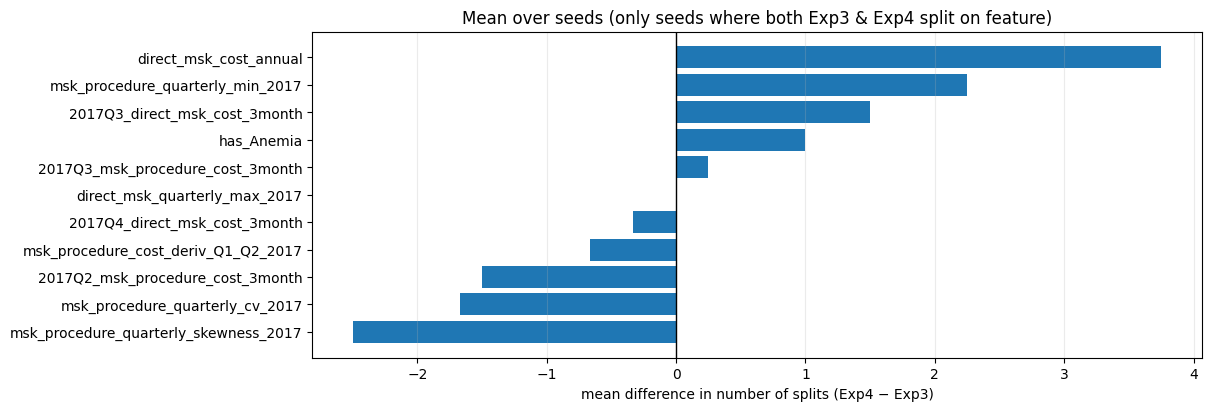

In [55]:
"""Restrict to (seed, feature) rows where that feature is used in both trees in that seed:
`exp3_count > 0 and exp4_count > 0`
Then aggregate (e.g. mean) only over those rows. 
Features that never have both positive in any seed won’t appear in the plot."""
tmp = feature_diff[feature_diff["feature"].isin(top_features)].copy()

both = tmp[(tmp["exp3_count"] > 0) & (tmp["exp4_count"] > 0)].copy()

avg = (
    both.groupby("feature", as_index=False)["count_diff_exp4_minus_exp3"]
    .mean()
    .sort_values("count_diff_exp4_minus_exp3")
)

fig, ax = plt.subplots(figsize=(12, max(4, 0.35 * len(avg))), constrained_layout=True)
ax.barh(avg["feature"], avg["count_diff_exp4_minus_exp3"])
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Mean over seeds (only seeds where both Exp3 & Exp4 split on feature)")
ax.set_xlabel("mean difference in number of splits (Exp4 − Exp3)")
ax.grid(True, axis="x", alpha=0.25)
plt.show()

### Feature family analysis 

In [56]:
# --- feature family mapping ---
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def feature_family(feat: str) -> str:
    f = str(feat).lower()

    # diagnosis / binary flags
    if f.startswith("has_") or f.startswith("is_") or f.endswith("_adherent"):
        return "diagnosis_flag"

    # temporal change / derivative
    if "_deriv_" in f:
        return "derivative_change"

    # dispersion / shape summaries
    if any(tok in f for tok in ["_std_", "_cv_", "_skewness_", "_kurtosis_", "_range_"]):
        return "dispersion_shape"

    # extrema summaries
    if any(tok in f for tok in ["_min_", "_max_"]):
        return "extrema"

    # annual / quarterly / 3-month level summaries
    if any(tok in f for tok in ["_3month", "_annual"]):
        return "level_summary"

    return "other"


def source_family(feat: str) -> str:
    f = str(feat).lower()

    if "procedure" in f:
        return "procedure"
    if "direct_msk" in f:
        return "direct_msk"
    if "comorbidity_only" in f:
        return "comorbidity_only"
    if f.startswith("has_") or f.startswith("is_"):
        return "diagnosis_flag"
    return "other"

In [65]:
# --- load BOTH unpruned and pruned split files ---
target_tags = ["exp3_mix", "exp4"]   # change exp4 label if needed

target_files_all = files_df[
    files_df["tag"].isin(target_tags) &
    files_df["variant"].isin(["unpruned", "pruned"])
].copy()

loaded = []
for _, row in target_files_all.iterrows():
    df = pd.read_csv(row["file"])
    tmp = standardize_split_df(df, row)
    loaded.append(tmp)

splits_master = pd.concat(loaded, ignore_index=True)

splits_master["family"] = splits_master["feature"].apply(feature_family)
splits_master["source_family"] = splits_master["feature"].apply(source_family)

display(splits_master.variant.value_counts())
print(splits_master.shape)

variant
unpruned    799
pruned      798
Name: count, dtype: int64

(1597, 11)


In [70]:
family_counts = (
    splits_master.groupby(["tag", "variant", "seed", "family"], as_index=False)
    .agg(n_splits=("feature", "size"))
)

family_counts["share"] = (
    family_counts["n_splits"] /
    family_counts.groupby(["tag", "variant", "seed"])["n_splits"].transform("sum")
)

#display(family_counts.head(20))
family_summary = (
    family_counts.groupby(["tag", "variant", "family"], as_index=False)
    .agg(
        mean_share=("share", "mean"),
        std_share=("share", "std"),
        mean_n_splits=("n_splits", "mean"),
    )
    .sort_values(["variant", "tag", "mean_share"], ascending=[True, True, False])
)

family_summary

,tag,variant,family,mean_share,std_share,mean_n_splits
4,exp3_mix,pruned,level_summary,0.373595,0.057822,37.50
2,exp3_mix,pruned,dispersion_shape,0.248693,0.015176,25.00
0,exp3_mix,pruned,derivative_change,0.143610,0.035760,14.50
5,exp3_mix,pruned,other,0.100065,0.038529,10.00
3,exp3_mix,pruned,extrema,0.067048,0.020236,6.75
1,exp3_mix,pruned,diagnosis_flag,0.066989,0.035670,6.75
16,exp4,pruned,level_summary,0.405512,0.061080,40.25
14,exp4,pruned,dispersion_shape,0.160896,0.053654,16.00
13,exp4,pruned,diagnosis_flag,0.139555,0.026278,13.75
17,exp4,pruned,other,0.114557,0.034196,11.25


['pruned', 'unpruned']
['derivative_change', 'diagnosis_flag', 'dispersion_shape', 'extrema', 'level_summary', 'other']


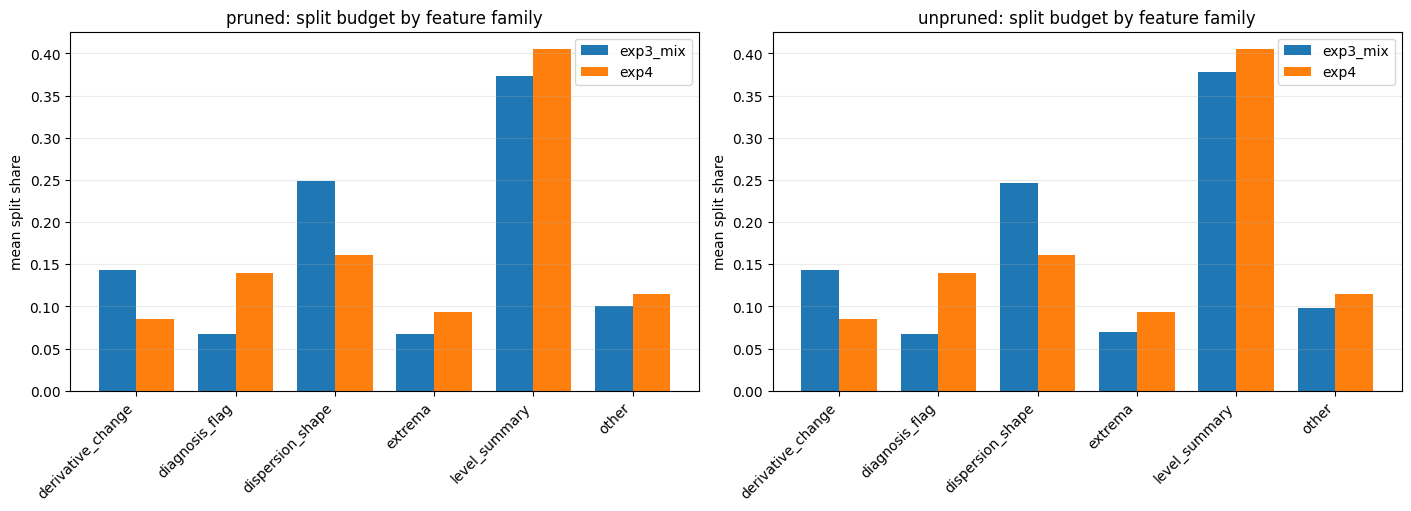

In [68]:
variants = sorted(family_summary["variant"].unique())
print(variants)
families = sorted(family_summary["family"].unique())
print(families)
fig, axes = plt.subplots(1, len(variants), figsize=(7 * len(variants), 5), constrained_layout=True)
if len(variants) == 1:
    axes = [axes]

for ax, variant in zip(axes, variants):
    d = family_summary[family_summary["variant"] == variant].copy()

    pivot = d.pivot(index="family", columns="tag", values="mean_share").fillna(0)
    pivot = pivot.loc[sorted(pivot.index)]

    x = np.arange(len(pivot.index))
    w = 0.38

    for i, tag in enumerate(pivot.columns):
        ax.bar(x + (i - 0.5) * w, pivot[tag].values, width=w, label=tag)

    ax.set_xticks(x)
    ax.set_xticklabels(pivot.index, rotation=45, ha="right")
    ax.set_ylabel("mean split share")
    ax.set_title(f"{variant}: split budget by feature family")
    ax.legend()
    ax.grid(True, axis="y", alpha=0.25)

plt.show()

### Feature-level prune survival

Now the second part: which features are consistently pruned vs retained.

In [39]:
feat_counts = (
    splits_master.groupby(["tag", "seed", "variant", "feature", "family", "source_family"], as_index=False)
    .agg(n_splits=("feature", "size"))
)

unpr = (
    feat_counts[feat_counts["variant"] == "unpruned"]
    .drop(columns="variant")
    .rename(columns={"n_splits": "n_unpruned"})
)
prun = (
    feat_counts[feat_counts["variant"] == "pruned"]
    .drop(columns="variant")
    .rename(columns={"n_splits": "n_pruned"})
)
print(len(unpr), len(prun))

prune_compare = unpr.merge(
    prun,
    on=["tag", "seed", "feature", "family", "source_family"],
    how="outer"
).fillna({"n_unpruned": 0, "n_pruned": 0})

prune_compare["n_unpruned"] = prune_compare["n_unpruned"].astype(int)
prune_compare["n_pruned"] = prune_compare["n_pruned"].astype(int)

prune_compare["n_pruned_away"] = prune_compare["n_unpruned"] - prune_compare["n_pruned"]
prune_compare["survival_rate"] = np.where(
    prune_compare["n_unpruned"] > 0,
    prune_compare["n_pruned"] / prune_compare["n_unpruned"],
    np.nan
)
prune_stability = (
    prune_compare.groupby(["tag", "feature", "family", "source_family"], as_index=False)
    .agg(
        seeds_unpruned=("n_unpruned", lambda x: int((x > 0).sum())),
        mean_unpruned=("n_unpruned", "mean"),
        mean_pruned=("n_pruned", "mean"),
        mean_survival_rate=("survival_rate", "mean"),
        median_survival_rate=("survival_rate", "median"),
        fully_pruned_in_n_seeds=("survival_rate", lambda x: int(np.nansum(x == 0))),
        fully_survived_in_n_seeds=("survival_rate", lambda x: int(np.nansum(x == 1))),
    )
)



356 357


In [38]:
print("Features that consistently survived")
consistently_survived = prune_stability[
    (prune_stability["seeds_unpruned"] >= 3) &
    (prune_stability["mean_survival_rate"] >= 0.75)
].sort_values(["tag", "mean_survival_rate", "seeds_unpruned"], ascending=[True, False, False])

display(consistently_survived)

Features that consistently survived


,tag,feature,family,source_family,seeds_unpruned,mean_unpruned,mean_pruned,mean_survival_rate,median_survival_rate,fully_pruned_in_n_seeds,fully_survived_in_n_seeds
42,exp3_mix,direct_msk_quarterly_std_2017,dispersion_shape,direct_msk,3,1.333333,1.666667,1.333333,1.0,0,2
1,exp3_mix,2017Q1_direct_msk_cost_3month,level_summary,direct_msk,4,2.500000,2.500000,1.000000,1.0,0,4
2,exp3_mix,2017Q1_msk_procedure_cost_3month,level_summary,procedure,4,2.250000,2.250000,1.000000,1.0,0,4
3,exp3_mix,2017Q2_direct_msk_cost_3month,level_summary,direct_msk,4,2.250000,2.250000,1.000000,1.0,0,4
4,exp3_mix,2017Q2_msk_procedure_cost_3month,level_summary,procedure,4,4.250000,4.250000,1.000000,1.0,0,4
...,...,...,...,...,...,...,...,...,...,...,...
118,exp4,has_Long_term_Drug_Therapy,diagnosis_flag,diagnosis_flag,3,1.666667,1.666667,1.000000,1.0,0,3
127,exp4,msk_procedure_cost_deriv_Q1_Q2_2017,derivative_change,procedure,3,2.000000,2.000000,1.000000,1.0,0,3
134,exp4,msk_procedure_quarterly_cv_2017,dispersion_shape,procedure,3,2.000000,2.000000,1.000000,1.0,0,3
135,exp4,msk_procedure_quarterly_kurtosis_2017,dispersion_shape,procedure,3,2.333333,2.333333,1.000000,1.0,0,3


In [41]:
left = (
    prune_stability[prune_stability["tag"] == "exp3_mix"]
    .drop(columns="tag")
    .rename(columns={
        "seeds_unpruned": "exp3_seeds_unpruned",
        "seeds_pruned_retained": "exp3_seeds_retained",
        "mean_unpruned": "exp3_mean_unpruned",
        "mean_pruned": "exp3_mean_pruned",
        "mean_survival_rate": "exp3_mean_survival",
        "median_survival_rate": "exp3_median_survival",
        "fully_pruned_in_n_seeds": "exp3_fully_pruned_n",
        "fully_survived_in_n_seeds": "exp3_fully_survived_n",
    })
)

right = (
    prune_stability[prune_stability["tag"] == "exp4"]
    .drop(columns="tag")
    .rename(columns={
        "seeds_unpruned": "exp4_seeds_unpruned",
        "seeds_pruned_retained": "exp4_seeds_retained",
        "mean_unpruned": "exp4_mean_unpruned",
        "mean_pruned": "exp4_mean_pruned",
        "mean_survival_rate": "exp4_mean_survival",
        "median_survival_rate": "exp4_median_survival",
        "fully_pruned_in_n_seeds": "exp4_fully_pruned_n",
        "fully_survived_in_n_seeds": "exp4_fully_survived_n",
    })
)

survival_diff = left.merge(
    right,
    on=["feature", "family", "source_family"],
    how="outer"
)

survival_diff["survival_diff_exp4_minus_exp3"] = (
    survival_diff["exp4_mean_survival"] - survival_diff["exp3_mean_survival"]
)


In [ ]:


# features with strong pruning-survival difference
stable_survival = survival_diff.copy()

# adjust thresholds if needed
stable_survival = stable_survival[
    (
        stable_survival[["exp3_seeds_unpruned", "exp4_seeds_unpruned"]]
        .max(axis=1) >= 3
    )
].copy()

stable_survival["abs_survival_diff"] = stable_survival["survival_diff_exp4_minus_exp3"].abs()

# optionally merge in split-count asymmetry
feat_strength = feature_diff.groupby("feature", as_index=False).agg(
    mean_abs_split_diff=("abs_count_diff", "mean")
)

stable_survival = stable_survival.merge(feat_strength, on="feature", how="left")

# combined ranking score
stable_survival["priority_score"] = (
    stable_survival["abs_survival_diff"].fillna(0)
    + 0.15 * stable_survival["mean_abs_split_diff"].fillna(0)
)

stable_survival = stable_survival.sort_values("priority_score", ascending=False)

# top features surviving more in Exp4
top_exp4 = (
    stable_survival[stable_survival["survival_diff_exp4_minus_exp3"] > 0]
    .sort_values("priority_score", ascending=False)
    .head(5)["feature"]
    .tolist()
)

# top features surviving more in Exp3
top_exp3 = (
    stable_survival[stable_survival["survival_diff_exp4_minus_exp3"] < 0]
    .sort_values("priority_score", ascending=False)
    .head(5)["feature"]
    .tolist()
)

selected_features = top_exp4 + top_exp3
print("Top features surviving more in Exp4:")
print(top_exp4)
print("\nTop features surviving more in Exp3:")
print(top_exp3)



Top features surviving more in Exp4:
['direct_msk_cost_annual', 'direct_msk_quarterly_max_2017', '2017Q4_msk_procedure_cost_3month']

Top features surviving more in Exp3:
['direct_msk_quarterly_std_2017']


## Scatter Plotting 

In [22]:
selected_features = ['direct_msk_cost_annual', 'direct_msk_quarterly_max_2017', '2017Q4_msk_procedure_cost_3month']

(251110, 115) (10188, 99) (10188, 99)
Missing selected features: []


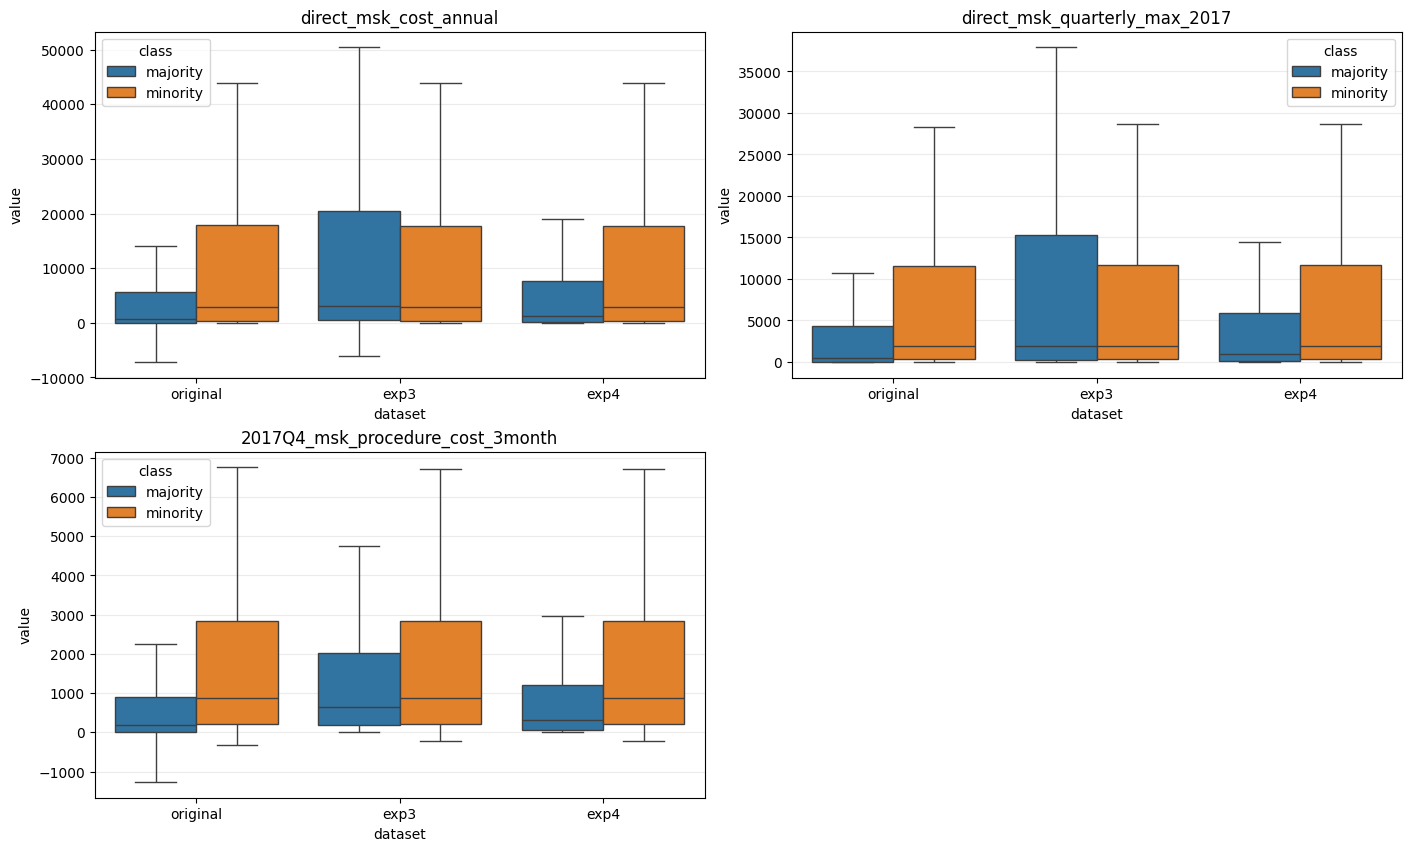

In [38]:
from pathlib import Path
import numpy as np
import pandas as pd
seed = 5
target_col = "top_2_pct_cost_2018"   # change this
base_compare = Path("/Users/cat2510/my_projects/msk_analysis/compare_oct_cp0_rnd_v_exp4_train_sets")

# original full train data
orig_path = Path("/Users/cat2510/my_projects/msk_analysis/msk_2017_18_full.parquet")  # change this

# sampled train sets
exp3_path = base_compare / f"exp3_mix_s{seed}_train.csv"
exp4_path = base_compare / f"exp4_matched_1N_plus_1N_random_s{seed}_train.csv"

orig_df = pd.read_parquet(orig_path)
exp3_df = pd.read_csv(exp3_path)
exp4_df = pd.read_csv(exp4_path)

print(orig_df.shape, exp3_df.shape, exp4_df.shape)
def prep_long(df, dataset_name, feature_list, target_col):
    cols = [c for c in feature_list if c in df.columns]
    out = df[cols + [target_col]].copy()
    out["dataset"] = dataset_name
    out["class_label"] = np.where(out[target_col] == 1, "minority", "majority")
    return out

plot_df = pd.concat([
    prep_long(orig_df, "original", selected_features, target_col),
    prep_long(exp3_df, "exp3", selected_features, target_col),
    prep_long(exp4_df, "exp4", selected_features, target_col),
], ignore_index=True)

missing = [f for f in selected_features if f not in plot_df.columns]
print("Missing selected features:", missing)
import matplotlib.pyplot as plt
import seaborn as sns

features_to_plot = [f for f in selected_features if f in plot_df.columns]

n = len(features_to_plot)
ncols = 2
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4.2 * nrows), constrained_layout=True)
axes = np.array(axes).reshape(-1)

for ax, feat in zip(axes, features_to_plot):
    d = plot_df[["dataset", "class_label", feat]].dropna().copy()
    d = d.rename(columns={feat: "value"})

    sns.boxplot(
        data=d,
        x="dataset",
        y="value",
        hue="class_label",
        ax=ax,
        showfliers=False
    )
    ax.set_title(feat)
    ax.grid(True, axis="y", alpha=0.25)
    ax.legend_.set_title("class")

for ax in axes[len(features_to_plot):]:
    ax.axis("off")

plt.show()

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

seed = 5
target_col = "top_2_pct_cost_2018"      # change this
id_col = "ENROLID"        # change this

x_feat = "direct_msk_cost_annual"
y_feat = "direct_msk_quarterly_min_2017"


def _get_clip_bounds(s, lower, upper):
    lo, hi = s.quantile(lower), s.quantile(upper)
    return lo, hi


def plot_compare_oct_cp0_2d(
    orig_df,
    exp3_df,
    exp4_df,
    x_feat,
    y_feat,
    target_col="top_2_pct_cost_2018",
    id_col="ENROLID",
    scale="log",
    clip_quantiles=(0.001, 0.9999),
    clip_for_plot=False,
    figsize=(18, 5),
    title=None,
):
    """
    Three-panel scatter: original, Exp3-only majority overlay, Exp4-only majority overlay.
    Both axes use the same scale: raw or log1p. Use scale='log' or scale='raw'.
    If clip_for_plot is True, values are clipped to the quantiles and all are shown.
    If clip_for_plot is False, axis range is set to the quantiles but points outside are omitted.
    """
    for name, df in [("orig", orig_df), ("exp3", exp3_df), ("exp4", exp4_df)]:
        missing = [c for c in [id_col, target_col, x_feat, y_feat] if c not in df.columns]
        if missing:
            raise ValueError(f"{name} missing columns: {missing}")

    viz = orig_df[[id_col, target_col, x_feat, y_feat]].copy()
    exp3_ids = set(exp3_df.loc[exp3_df[target_col] == 0, id_col])
    exp4_ids = set(exp4_df.loc[exp4_df[target_col] == 0, id_col])
    viz["is_minority"] = viz[target_col] == 1
    viz["selected_exp3_only"] = viz[id_col].isin(exp3_ids - exp4_ids)
    viz["selected_exp4_only"] = viz[id_col].isin(exp4_ids - exp3_ids)

    lo, hi = clip_quantiles
    # For each axis get (lo, hi) bounds
    x_lo, x_hi = _get_clip_bounds(viz[x_feat], lo, hi)
    y_lo, y_hi = _get_clip_bounds(viz[y_feat], lo, hi)

    if clip_for_plot:
        viz_plot = viz.copy()
        viz_plot[x_feat + "_plot"] = viz_plot[x_feat].clip(x_lo, x_hi)
        viz_plot[y_feat + "_plot"] = viz_plot[y_feat].clip(y_lo, y_hi)
    else:
        viz_plot = viz[(viz[x_feat] >= x_lo) & (viz[x_feat] <= x_hi) & 
                       (viz[y_feat] >= y_lo) & (viz[y_feat] <= y_hi)].copy()
        viz_plot[x_feat + "_plot"] = viz_plot[x_feat]
        viz_plot[y_feat + "_plot"] = viz_plot[y_feat]

    if scale == "log":
        viz_plot[x_feat + "_plot"] = np.log1p(viz_plot[x_feat + "_plot"].clip(lower=0))
        viz_plot[y_feat + "_plot"] = np.log1p(viz_plot[y_feat + "_plot"].clip(lower=0))
        # Set axis limits in log scale
        log_x_lo = np.log1p(x_lo if x_lo >= 0 else 0)
        log_x_hi = np.log1p(x_hi if x_hi >= 0 else 0)
        log_y_lo = np.log1p(y_lo if y_lo >= 0 else 0)
        log_y_hi = np.log1p(y_hi if y_hi >= 0 else 0)
        xlim = (log_x_lo, log_x_hi)
        ylim = (log_y_lo, log_y_hi)
    else:
        xlim = (x_lo, x_hi)
        ylim = (y_lo, y_hi)

    xp, yp = x_feat + "_plot", y_feat + "_plot"
    fig, axes = plt.subplots(1, 3, figsize=figsize, constrained_layout=True, sharex=True, sharey=True)
    maj = viz_plot[~viz_plot["is_minority"]]
    mino = viz_plot[viz_plot["is_minority"]]
    n_exp3_only = viz_plot["selected_exp3_only"].sum()
    n_exp4_only = viz_plot["selected_exp4_only"].sum()

    # Panel 1: original only
    ax = axes[0]
    ax.scatter(maj[xp], maj[yp], s=10, alpha=0.45, color="gray", label="original majority")
    ax.scatter(mino[xp], mino[yp], s=10, alpha=0.45, color="orange", label="original minority")
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_title("Original data")
    ax.set_xlabel(x_feat + (" (log1p)" if scale == "log" else ""))
    ax.set_ylabel(y_feat + (" (log1p)" if scale == "log" else ""))
    ax.legend()
    ax.grid(True, alpha=0.25)

    # Panel 2: Exp3 overlay
    ax = axes[1]
    maj_sel = viz_plot[(~viz_plot["is_minority"]) & viz_plot["selected_exp3_only"]]
    ax.scatter(maj[xp], maj[yp], s=6, alpha=0.03, color="gray")
    ax.scatter(mino[xp], mino[yp], s=10, alpha=0.30, color="orange", label="minority")
    ax.scatter(maj_sel[xp], maj_sel[yp], s=16, alpha=0.60, color="green", label="Exp3-only majority")
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_title(f"Exp3-only majority (n={n_exp3_only})")
    if title:
        ax.set_title(f"Exp3-only {title} (n={n_exp3_only})")
    ax.set_xlabel(x_feat + (" (log1p)" if scale == "log" else ""))
    ax.legend()
    ax.grid(True, alpha=0.25)

    # Panel 3: Exp4 overlay
    ax = axes[2]
    maj_sel = viz_plot[(~viz_plot["is_minority"]) & viz_plot["selected_exp4_only"]]
    ax.scatter(maj[xp], maj[yp], s=6, alpha=0.03, color="gray")
    ax.scatter(mino[xp], mino[yp], s=10, alpha=0.30, color="orange", label="minority")
    ax.scatter(maj_sel[xp], maj_sel[yp], s=16, alpha=0.60, color="green", label="Exp4-only majority")
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_title(f"Exp4-only majority (n={n_exp4_only})")
    ax.set_xlabel(x_feat + (" (log1p)" if scale == "log" else ""))
    ax.legend()
    ax.grid(True, alpha=0.25)

    plt.show()
    return fig, axes


def plot_fn_fp_compare_2d(
    cmp,
    orig_df,
    x_feat,
    y_feat,
    target_col="top_2_pct_cost_2018",
    id_col="ENROLID",
    scale="log",
    clip_quantiles=(0.001, 0.999),
    clip_for_plot=False,
    figsize=(14, 10),
):
    """
    Four-panel scatter: Exp3-only FP, Exp4-only FP, Exp3-only FN, Exp4-only FN.
    cmp must have exp3_only_fp, exp4_only_fp, exp3_only_fn, exp4_only_fn and id_col, x_feat, y_feat, target_col.
    If clip_for_plot is True, values are clipped to the quantiles and all are shown.
    If clip_for_plot is False, axis range is set to the quantiles but points outside are omitted.
    """
    req = [id_col, x_feat, y_feat, target_col, "exp3_only_fp", "exp4_only_fp", "exp3_only_fn", "exp4_only_fn"]
    missing = [c for c in req if c not in cmp.columns]
    if missing:
        raise ValueError(f"cmp missing columns: {missing}")
    for c in [id_col, target_col, x_feat, y_feat]:
        if c not in orig_df.columns:
            raise ValueError(f"orig_df missing: {c}")

    viz = orig_df[[id_col, target_col, x_feat, y_feat]].merge(
        cmp[[id_col, "exp3_only_fp", "exp4_only_fp", "exp3_only_fn", "exp4_only_fn"]],
        on=id_col, how="left"
    ).fillna({"exp3_only_fp": False, "exp4_only_fp": False, "exp3_only_fn": False, "exp4_only_fn": False})
    viz["is_minority"] = viz[target_col] == 1

    lo, hi = clip_quantiles
    x_lo, x_hi = _get_clip_bounds(viz[x_feat], lo, hi)
    y_lo, y_hi = _get_clip_bounds(viz[y_feat], lo, hi)

    if clip_for_plot:
        viz[x_feat + "_plot"] = viz[x_feat].clip(x_lo, x_hi)
        viz[y_feat + "_plot"] = viz[y_feat].clip(y_lo, y_hi)
        plot_viz = viz
    else:
        plot_viz = viz[(viz[x_feat] >= x_lo) & (viz[x_feat] <= x_hi) &
                       (viz[y_feat] >= y_lo) & (viz[y_feat] <= y_hi)].copy()
        plot_viz[x_feat + "_plot"] = plot_viz[x_feat]
        plot_viz[y_feat + "_plot"] = plot_viz[y_feat]

    if scale == "log":
        plot_viz[x_feat + "_plot"] = np.log1p(plot_viz[x_feat + "_plot"].clip(lower=0))
        plot_viz[y_feat + "_plot"] = np.log1p(plot_viz[y_feat + "_plot"].clip(lower=0))
        log_x_lo = np.log1p(x_lo if x_lo >= 0 else 0)
        log_x_hi = np.log1p(x_hi if x_hi >= 0 else 0)
        log_y_lo = np.log1p(y_lo if y_lo >= 0 else 0)
        log_y_hi = np.log1p(y_hi if y_hi >= 0 else 0)
        xlim = (log_x_lo, log_x_hi)
        ylim = (log_y_lo, log_y_hi)
    else:
        xlim = (x_lo, x_hi)
        ylim = (y_lo, y_hi)

    xp, yp = x_feat + "_plot", y_feat + "_plot"
    maj = plot_viz[~plot_viz["is_minority"]]
    mino = plot_viz[plot_viz["is_minority"]]
    fig, axes = plt.subplots(2, 2, figsize=figsize, constrained_layout=True, sharex=True, sharey=True)

    def _panel(ax, overlay_mask, title, color="red"):
        ax.scatter(maj[xp], maj[yp], s=6, alpha=0.05, color="gray")
        ax.scatter(mino[xp], mino[yp], s=8, alpha=0.25, color="orange", label="minority")
        pts = plot_viz[overlay_mask]
        if len(pts) > 0:
            ax.scatter(pts[xp], pts[yp], s=20, alpha=0.7, color=color, label=f"n={len(pts)}")
        ax.set_xlim(*xlim)
        ax.set_ylim(*ylim)
        ax.set_title(title)
        ax.set_xlabel(x_feat + (" (log1p)" if scale == "log" else ""))
        ax.set_ylabel(y_feat + (" (log1p)" if scale == "log" else ""))
        ax.legend()
        ax.grid(True, alpha=0.25)

    _panel(axes[0, 0], plot_viz["exp3_only_fp"], "Exp3-only false positives", color="red")
    _panel(axes[0, 1], plot_viz["exp4_only_fp"], "Exp4-only false positives", color="red")
    _panel(axes[1, 0], plot_viz["exp3_only_fn"], "Exp3-only false negatives", color="blue")
    _panel(axes[1, 1], plot_viz["exp4_only_fn"], "Exp4-only false negatives", color="blue")

    plt.show()
    return fig, axes



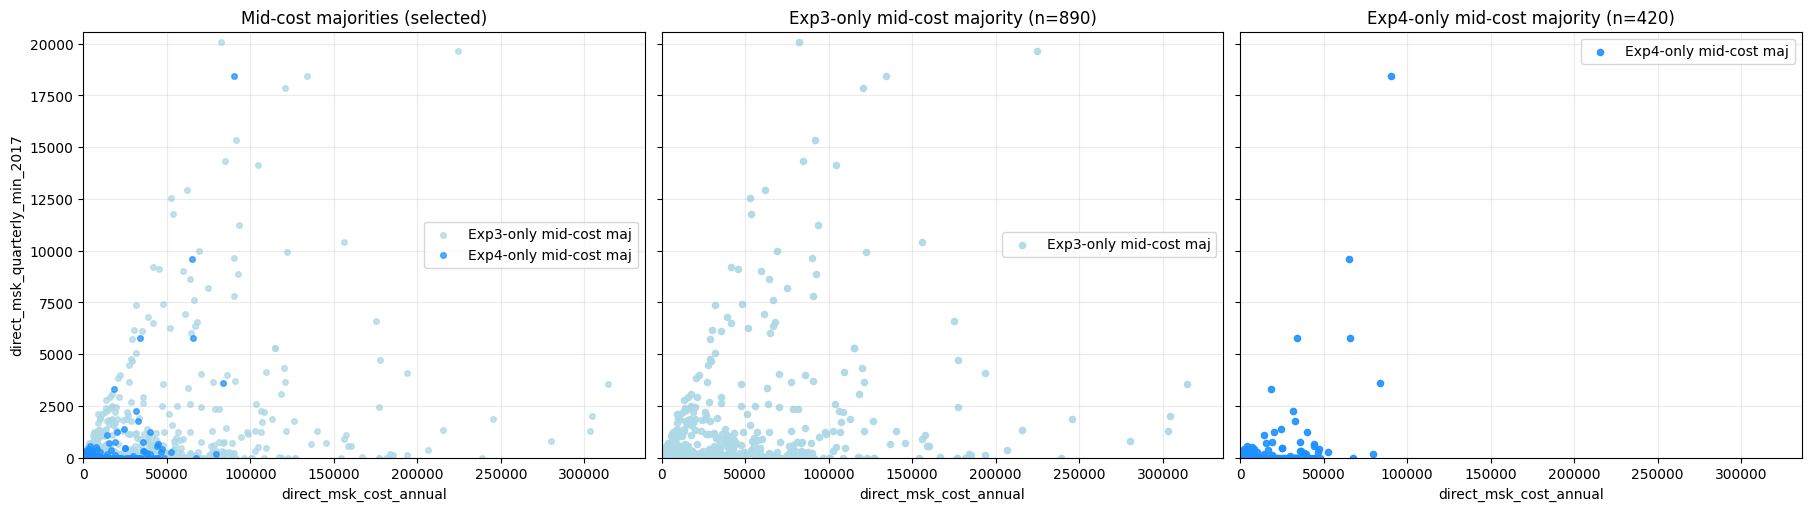

(<Figure size 1800x500 with 3 Axes>,
 array([<Axes: title={'center': 'Mid-cost majorities (selected)'}, xlabel='direct_msk_cost_annual', ylabel='direct_msk_quarterly_min_2017'>,
        <Axes: title={'center': 'Exp3-only mid-cost majority (n=890)'}, xlabel='direct_msk_cost_annual'>,
        <Axes: title={'center': 'Exp4-only mid-cost majority (n=420)'}, xlabel='direct_msk_cost_annual'>],
       dtype=object))

In [48]:

# Calculate the 80th and 98th percentiles of annual_cost_2018 in the original (full) dataframe.
cost_col = "annual_cost_2018_deflated"
cost_80 = orig_df[cost_col].quantile(0.85)
cost_98 = orig_df[cost_col].quantile(0.98)

def plot_compare_oct_cp0_2d_with_midcost_selected(
    orig_df,
    exp3_df,
    exp4_df,
    x_feat,
    y_feat,
    target_col="top_2_pct_cost_2018",
    id_col="ENROLID",
    scale="log",
    clip_quantiles=(0.001, 0.9999),
    figsize=(18, 5)
):
    # Check columns
    for name, df in [("orig", orig_df), ("exp3", exp3_df), ("exp4", exp4_df)]:
        missing = [c for c in [id_col, target_col, x_feat, y_feat] if c not in df.columns]
        if missing:
            raise ValueError(f"{name} missing columns: {missing}")
            
    viz = orig_df[[id_col, target_col, x_feat, y_feat]].copy()
    exp3_ids = set(exp3_df.loc[exp3_df[target_col] == 0, id_col])
    exp4_ids = set(exp4_df.loc[exp4_df[target_col] == 0, id_col])
    viz["is_minority"] = viz[target_col] == 1
    viz["selected_exp3_only"] = viz[id_col].isin(exp3_ids - exp4_ids)
    viz["selected_exp4_only"] = viz[id_col].isin(exp4_ids - exp3_ids)
    n_exp3_only = viz["selected_exp3_only"].sum()
    n_exp4_only = viz["selected_exp4_only"].sum()
    
    lo, hi = clip_quantiles
    x_lo, x_hi = _get_clip_bounds(viz[x_feat], lo, hi)
    y_lo, y_hi = _get_clip_bounds(viz[y_feat], lo, hi)
    
    plot_viz = viz[(viz[x_feat] >= x_lo) & (viz[x_feat] <= x_hi) &
                   (viz[y_feat] >= y_lo) & (viz[y_feat] <= y_hi)].copy()
    plot_viz[x_feat + "_plot"] = plot_viz[x_feat]
    plot_viz[y_feat + "_plot"] = plot_viz[y_feat]
    
    if scale == "log":
        plot_viz[x_feat + "_plot"] = np.log1p(plot_viz[x_feat + "_plot"].clip(lower=0))
        plot_viz[y_feat + "_plot"] = np.log1p(plot_viz[y_feat + "_plot"].clip(lower=0))
        log_x_lo = np.log1p(x_lo if x_lo >= 0 else 0)
        log_x_hi = np.log1p(x_hi if x_hi >= 0 else 0)
        log_y_lo = np.log1p(y_lo if y_lo >= 0 else 0)
        log_y_hi = np.log1p(y_hi if y_hi >= 0 else 0)
        xlim = (log_x_lo, log_x_hi)
        ylim = (log_y_lo, log_y_hi)
    else:
        xlim = (x_lo, x_hi)
        ylim = (y_lo, y_hi)
        
    xp, yp = x_feat + "_plot", y_feat + "_plot"
    # Attach annual cost if missing
    if cost_col not in plot_viz.columns:
        plot_viz = plot_viz.merge(orig_df[[id_col, cost_col]], on=id_col, how='left')
    maj = plot_viz[~plot_viz["is_minority"]]
    mino = plot_viz[plot_viz["is_minority"]]  # Not plotted in midcost overlays anymore
    
    # Filter for midcost majority points selected by exp3 or exp4
    midcost_maj_exp3 = maj[
        (maj[cost_col] >= cost_80) & (maj[cost_col] < cost_98) & (maj["selected_exp3_only"])
    ]
    midcost_maj_exp4 = maj[
        (maj[cost_col] >= cost_80) & (maj[cost_col] < cost_98) & (maj["selected_exp4_only"])
    ]
    
    fig, axes = plt.subplots(1, 3, figsize=figsize, constrained_layout=True, sharex=True, sharey=True)
    
    # Panel 1: Both overlays for "midcost selected"
    ax = axes[0]
    ax.scatter(midcost_maj_exp3[xp], midcost_maj_exp3[yp], s=16, alpha=0.75, color="lightblue", label="Exp3-only mid-cost maj")
    ax.scatter(midcost_maj_exp4[xp], midcost_maj_exp4[yp], s=16, alpha=0.75, color="dodgerblue", label="Exp4-only mid-cost maj")
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_title("Mid-cost majorities (selected)")
    ax.set_xlabel(x_feat + (" (log1p)" if scale == "log" else ""))
    ax.set_ylabel(y_feat + (" (log1p)" if scale == "log" else ""))
    ax.legend()
    ax.grid(True, alpha=0.25)
    
    # Panel 2: Exp3-only midcost majorities
    ax = axes[1]
    ax.scatter(midcost_maj_exp3[xp], midcost_maj_exp3[yp], s=20, alpha=0.90, color="lightblue", label="Exp3-only mid-cost maj")
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_title(f"Exp3-only mid-cost majority (n={len(midcost_maj_exp3)})")
    ax.set_xlabel(x_feat + (" (log1p)" if scale == "log" else ""))
    ax.legend()
    ax.grid(True, alpha=0.25)
    
    # Panel 3: Exp4-only midcost majorities
    ax = axes[2]
    ax.scatter(midcost_maj_exp4[xp], midcost_maj_exp4[yp], s=20, alpha=0.90, color="dodgerblue", label="Exp4-only mid-cost maj")
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_title(f"Exp4-only mid-cost majority (n={len(midcost_maj_exp4)})")
    ax.set_xlabel(x_feat + (" (log1p)" if scale == "log" else ""))
    ax.legend()
    ax.grid(True, alpha=0.25)
    
    plt.show()
    return fig, axes

# Call the new plotting function
plot_compare_oct_cp0_2d_with_midcost_selected(
    orig_df, exp3_df, exp4_df,
    x_feat=x_feat,
    y_feat=y_feat,
    target_col=target_col,
    id_col=id_col,
    scale="raw",  # or "raw" for both axes raw (clipped)
)


In [2]:
import sys
import os
# repo imports
# In Jupyter notebooks, __file__ is not defined; use current working directory
script_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(script_dir, "../../"))
sys.path.insert(0, parent_dir)
sys.path.insert(0, script_dir)
from public.model_IAI import train_test_split_enrol
# must match the script exactly
PARQUET_PATH = "/Users/cat2510/my_projects/msk_analysis/msk_2017_18_no_meds.parquet" # TODO: change to full
TARGET_COL = "top_2_pct_cost_2018"
TRAIN_TEST_SEED = 123     # use the exact value from your script

df = pd.read_parquet(PARQUET_PATH)

_, _, train_pd, test_pd = train_test_split_enrol(
        df, target_col=TARGET_COL, test_size=0.3, verbose=False,
        random_state=TRAIN_TEST_SEED,
    )
_, _, val_pd, test_pd = train_test_split_enrol(
    test_pd, target_col=TARGET_COL, test_size=0.5, verbose=False,
    random_state=TRAIN_TEST_SEED,
)
print(test_pd.shape)

(37667, 99)


In [3]:
# check if the ENROLID train_ids_set are distinct from the ENROLID in test_ids
overlap = set(train_pd["ENROLID"]) & set(test_pd["ENROLID"])
print(f"Overlap: {len(overlap)}")

Overlap: 0


In [4]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

seed = 100
base = Path("/Users/cat2510/my_projects/msk_analysis/compare_oct_cp0_gower_v2")

exp3_pred_path = base / f"exp3_mix_s{seed}" / "predictions" / f"oct_predictions_exp3_mix_s{seed}_pruned_d7_mb5_cp1e-05.csv"
exp4_pred_path = base / f"exp4_matched_plus_random_s{seed}" / "predictions" / f"oct_predictions_exp4_matched_plus_random_s{seed}_pruned_d7_mb5_cp1e-05.csv"

exp3_pred = pd.read_csv(exp3_pred_path)
exp4_pred = pd.read_csv(exp4_pred_path)

print(exp3_pred.shape, exp4_pred.shape)
print(exp3_pred.columns.tolist())
def attach_test_ids_and_labels_by_position(pred_df, test_df, target_col="top_2_pct_cost_2018"):
    if len(pred_df) != len(test_df):
        raise ValueError(f"Length mismatch: pred_df={len(pred_df)}, test_df={len(test_df)}")
    out = pred_df.copy().reset_index(drop=True)
    test_aligned = test_df.reset_index(drop=True)
    out["y_true"] = test_aligned[target_col].values
    return out
check_cols = [
    "has_Anemia",
    "has_Vitamin_D_Deficiency",
    "has_Dorsopathies",
]

for c in check_cols:
    same_exp3 = np.allclose(
        exp3_pred[c].to_numpy(),
        test_pd[c].reset_index(drop=True).to_numpy(),
        equal_nan=True
    )
    same_exp4 = np.allclose(
        exp4_pred[c].to_numpy(),
        test_pd[c].reset_index(drop=True).to_numpy(),
        equal_nan=True
    )
    print(c, same_exp3, same_exp4)
exp3_pred_aligned = attach_test_ids_and_labels_by_position(exp3_pred, test_pd, target_col=TARGET_COL)
exp4_pred_aligned = attach_test_ids_and_labels_by_position(exp4_pred, test_pd, target_col=TARGET_COL)

(37667, 119) (37667, 119)
['ENROLID', 'direct_msk_cost_pattern_2017_early_heavy', 'direct_msk_cost_pattern_2017_late_heavy', 'direct_msk_cost_stability_2017_moderate', 'direct_msk_cost_stability_2017_stable', 'msk_procedure_cost_pattern_2017_early_heavy', 'msk_procedure_cost_pattern_2017_late_heavy', 'msk_procedure_cost_stability_2017_moderate', 'msk_procedure_cost_stability_2017_stable', 'comorbidity_only_cost_pattern_2017_early_heavy', 'comorbidity_only_cost_pattern_2017_late_heavy', 'comorbidity_only_cost_stability_2017_moderate', 'comorbidity_only_cost_stability_2017_stable', 'AGEGRP_2', 'AGEGRP_3', 'AGEGRP_4', 'AGEGRP_5', 'AGEGRP_6', 'SEX_2', 'REGION_2', 'REGION_3', 'REGION_4', 'REGION_5', 'EESTATU_2', 'EESTATU_3', 'EESTATU_4', 'EESTATU_5', 'EESTATU_6', 'EESTATU_7', 'EESTATU_8', 'EESTATU_9', '2017Q1_direct_msk_cost_3month', '2017Q1_msk_procedure_cost_3month', '2017Q1_comorbidity_only_cost_3month', '2017Q2_direct_msk_cost_3month', '2017Q2_msk_procedure_cost_3month', '2017Q2_comorbi

In [5]:
pred_col = "predicted_class_default"
id_col = "ENROLID"
for df in [exp3_pred_aligned, exp4_pred_aligned]:
    df["y_pred"] = df[pred_col].astype(int)
    df["is_misclassified"] = df["y_pred"] != df["y_true"]
    df["is_fn"] = (df["y_true"] == 1) & (df["y_pred"] == 0)
    df["is_fp"] = (df["y_true"] == 0) & (df["y_pred"] == 1)

# outcome comparison table
cmp = exp3_pred_aligned[[id_col, "y_true", "y_pred", "is_misclassified", "is_fn", "is_fp"]].merge(
    exp4_pred_aligned[[id_col, "y_true", "y_pred", "is_misclassified", "is_fn", "is_fp"]],
    on=[id_col, "y_true"],
    suffixes=("_exp3", "_exp4"),
    validate="1:1"
)

# add raw coordinates for plotting
cmp = cmp.merge(
    test_pd[[id_col, x_feat, y_feat]],
    on=id_col,
    how="left",
    validate="1:1"
)

# disagreement flags
cmp["exp3_only_mis"] = cmp["is_misclassified_exp3"] & (~cmp["is_misclassified_exp4"])
cmp["exp4_only_mis"] = cmp["is_misclassified_exp4"] & (~cmp["is_misclassified_exp3"])
cmp["both_mis"] = cmp["is_misclassified_exp3"] & cmp["is_misclassified_exp4"]

cmp["exp3_only_fn"] = cmp["is_fn_exp3"] & (~cmp["is_fn_exp4"])
cmp["exp4_only_fn"] = cmp["is_fn_exp4"] & (~cmp["is_fn_exp3"])

cmp["exp3_only_fp"] = cmp["is_fp_exp3"] & (~cmp["is_fp_exp4"])
cmp["exp4_only_fp"] = cmp["is_fp_exp4"] & (~cmp["is_fp_exp3"])

# Add TARGET_COL so plot_compare_oct_cp0_2d can use it (test_pd has top_2_pct_cost_2018, not y_true)
cmp[TARGET_COL] = cmp["y_true"]

print(cmp.columns.tolist())
print(cmp[[id_col, x_feat, y_feat]].head())

['ENROLID', 'y_true', 'y_pred_exp3', 'is_misclassified_exp3', 'is_fn_exp3', 'is_fp_exp3', 'y_pred_exp4', 'is_misclassified_exp4', 'is_fn_exp4', 'is_fp_exp4', 'direct_msk_cost_annual', 'msk_procedure_quarterly_min_2017', 'exp3_only_mis', 'exp4_only_mis', 'both_mis', 'exp3_only_fn', 'exp4_only_fn', 'exp3_only_fp', 'exp4_only_fp', 'top_2_pct_cost_2018']
    ENROLID  direct_msk_cost_annual  msk_procedure_quarterly_min_2017
0  26975501                 9756.71                              0.00
1  27181905                54013.37                            374.98
2  27302101                12477.15                              0.00
3  28260601                 4095.13                              0.00
4  28574606                    0.00                              0.00


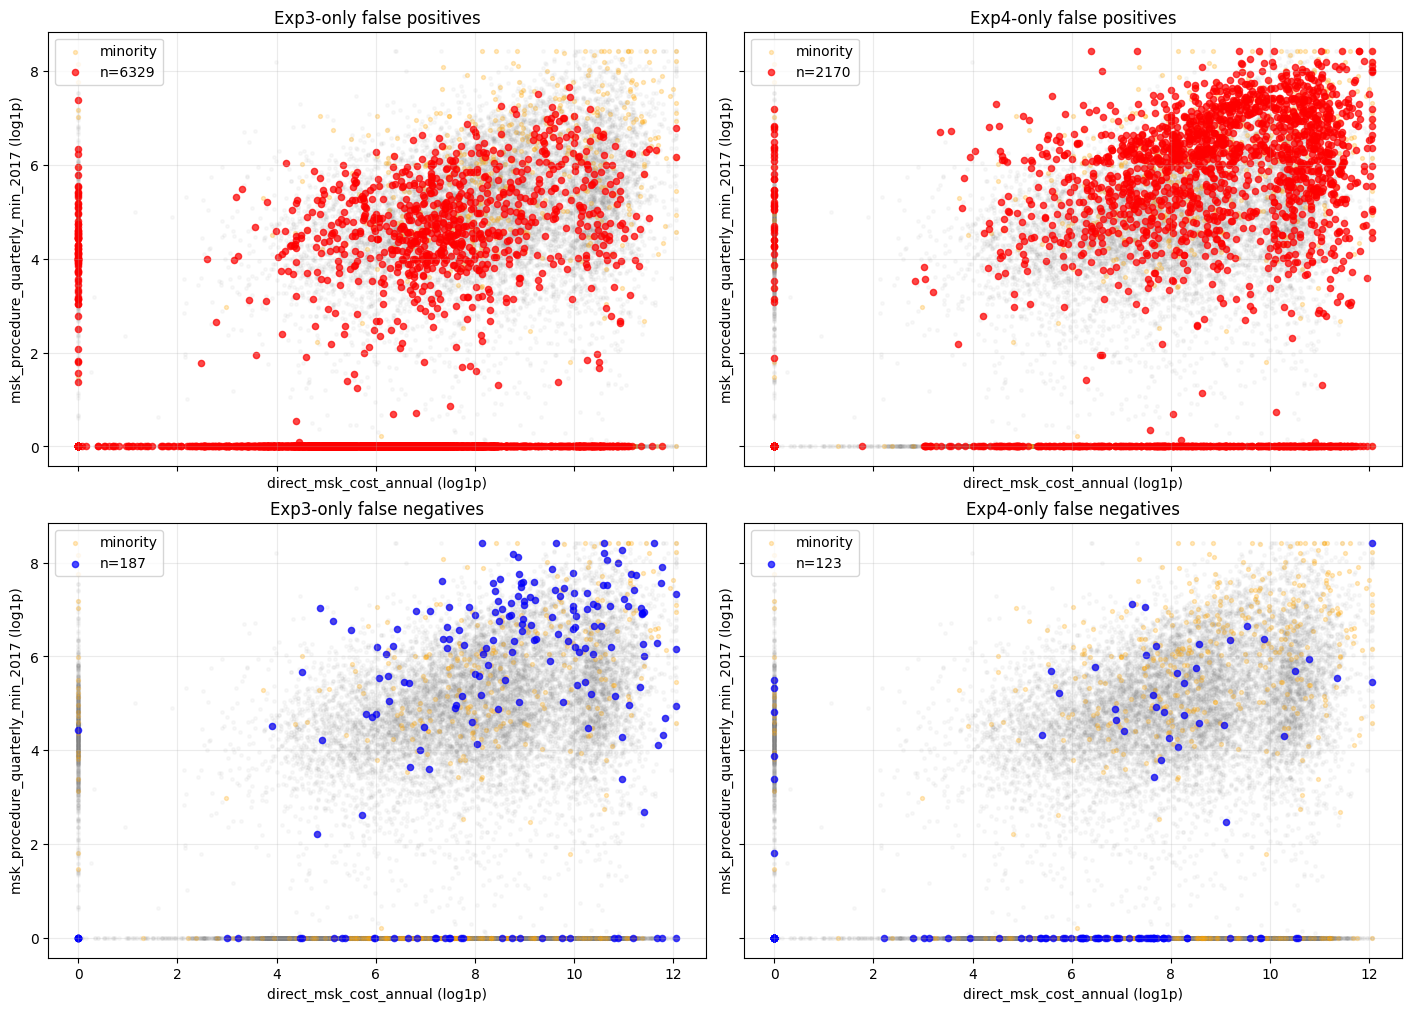

(<Figure size 1400x1000 with 4 Axes>,
 array([[<Axes: title={'center': 'Exp3-only false positives'}, xlabel='direct_msk_cost_annual (log1p)', ylabel='msk_procedure_quarterly_min_2017 (log1p)'>,
         <Axes: title={'center': 'Exp4-only false positives'}, xlabel='direct_msk_cost_annual (log1p)', ylabel='msk_procedure_quarterly_min_2017 (log1p)'>],
        [<Axes: title={'center': 'Exp3-only false negatives'}, xlabel='direct_msk_cost_annual (log1p)', ylabel='msk_procedure_quarterly_min_2017 (log1p)'>,
         <Axes: title={'center': 'Exp4-only false negatives'}, xlabel='direct_msk_cost_annual (log1p)', ylabel='msk_procedure_quarterly_min_2017 (log1p)'>]],
       dtype=object))

In [7]:
# Plot false positives and false negatives: Exp3 vs Exp4
plot_fn_fp_compare_2d(
    cmp=cmp,
    orig_df=test_pd,
    x_feat=x_feat,
    y_feat=y_feat,
    target_col=TARGET_COL,
    id_col=id_col,
    scale="log",
)

## OTHER

In [4]:
from pathlib import Path

seed = 100
base_compare = Path("/Users/cat2510/my_projects/msk_analysis/compare_oct_cp0_gower_v2/")

# original full train data
orig_path = Path("/Users/cat2510/my_projects/msk_analysis/msk_2017_18_full.parquet")  # change this

# sampled train sets
exp3_path = base_compare / f"exp3_mix_s{seed}" / f"leaf_train_pruned.csv"
exp4_path = base_compare / f"exp4_matched_plus_random_s{seed}" / f"leaf_train_pruned.csv"

orig_df = pd.read_parquet(orig_path)
exp3_df = pd.read_csv(exp3_path)
exp4_df = pd.read_csv(exp4_path)

print(orig_df.shape, exp3_df.shape, exp4_df.shape)

(251110, 115) (106, 4) (109, 4)


In [11]:
import pandas as pd

# load
df = pd.read_csv("../../../scratch/msk_analysis/exp_0_to_4_gower_v2/results/experiment_summary.csv")

# keep only exp3 / exp4
sub = df[
    #df["experiment"].isin(["exp3", "exp4"]) &
    df["seed"].isin(range(100, 150))
].copy()

print(sub.shape)
# metrics to summarize
metrics = [
    "auc",
    "pr_auc",
    "best_mcc",
    "recall_mcc",
    "specificity_mcc",
    "optimal_f1",
    "balanced_recall_gmean",
    "balanced_specificity_gmean",
    "recall_at_specificity_0.6",
    "achieved_specificity_0.6",
]

# mean + std summary
summary = (
    sub.groupby(["experiment", "variant"])[metrics]
      .agg(["mean", "std"])
      .round(4)
)

display(summary)

(250, 20)


auc          pr_auc         best_mcc  \
                                        mean     std    mean     std     mean   
experiment variant                                                              
exp0_rnd   random                     0.7441  0.0095  0.0634  0.0036   0.1475   
exp1       stageA                     0.4273  0.0315  0.0169  0.0016   0.0058   
exp2       stageB                     0.6797  0.0263  0.0576  0.0035   0.1458   
exp3       mix                        0.5271  0.0404  0.0300  0.0044   0.0728   
exp4       matched_1N_plus_1N_random  0.7157  0.0193  0.0609  0.0041   0.1484   

                                             recall_mcc          \
                                         std       mean     std   
experiment variant                                                
exp0_rnd   random                     0.0061     0.4621  0.0626   
exp1       stageA                     0.0108     0.6970  0.3958   
exp2       stageB                     0.0050     0.3893  0.0543   
exp3       mix                        0.0142     0.1674  0.1292   
exp4       matched_1N_plus_1N_random  0.0046     0.4498  0.0583   

                                     specificity_mcc         optimal_f1  \
                                                mean     std       mean   
experiment variant                                                        
exp0_rnd   random                             0.8854  0.0253     0.1390   
exp1       stageA                             0.3173  0.4120     0.0400   
exp2       stageB                             0.9141  0.0193     0.1443   
exp3       mix                                0.9421  0.0680     0.0868   
exp4       matched_1N_plus_1N_random          0.8917  0.0239     0.1413   

                                             balanced_recall_gmean          \
                                         std                  mean     std   
experiment variant                                                           
exp0_rnd   random                     0.0084                0.6472  0.0523   
exp1       stageA                     0.0045                0.4280  0.0830   
exp2       stageB                     0.0075                0.5351  0.1290   
exp3       mix                        0.0145                0.4618  0.1113   
exp4       matched_1N_plus_1N_random  0.0073                0.6011  0.0702   

                                     balanced_specificity_gmean          \
                                                           mean     std   
experiment variant                                                        
exp0_rnd   random                                        0.7544  0.0583   
exp1       stageA                                        0.5019  0.0763   
exp2       stageB                                        0.7876  0.1312   
exp3       mix                                           0.6531  0.1418   
exp4       matched_1N_plus_1N_random                     0.7636  0.0818   

                                     recall_at_specificity_0.6          \
                                                          mean     std   
experiment variant                                                       
exp0_rnd   random                                       0.6715  0.0588   
exp1       stageA                                       0.2787  0.0673   
exp2       stageB                                       0.4823  0.0852   
exp3       mix                                          0.3935  0.0818   
exp4       matched_1N_plus_1N_random                    0.6151  0.0740   

                                     achieved_specificity_0.6          
                                                         mean     std  
experiment variant                                                     
exp0_rnd   random                                      0.7220  0.0703  
exp1       stageA                                      0.6483  0.0564  
exp2       stageB                                      0.8358  0.0888  
exp

In [20]:
# For exp0_rnd, compute the diversity of features across seeds:
# Find the union of selected features (absolute and relative to total features)

exp_name = "exp2_stageB"
exp0_seeds = sub[sub["experiment"] == "exp2"]["seed"].unique()

# We'll collect features-per-seed here
features_per_seed = []
for seed in exp0_seeds:
    # Path for this seed's leaf_train_pruned (adjust as appropriate)
    # The splits/features are stored in the following CSV files, with columns: node_id, feature, threshold
    leaf_path = Path(f"/Users/cat2510/scratch/msk_analysis/exp_0_to_4_gower_v2/results/oct_tree_{exp_name}_s{seed}_splits.csv")
    if leaf_path.exists():
        leaf_df = pd.read_csv(leaf_path)
        # Assume 'feature' column holds the selected features
        sel_feats = set(leaf_df["feature"])
        features_per_seed.append(sel_feats)
    else:
        print(f"Warning: File not found: {leaf_path}")

# Union of all selected features across seeds
if features_per_seed:
    union_features = set().union(*features_per_seed)
    n_union = len(union_features)
    # count total number of candidate features (e.g. from original data)
    # assumes orig_df loaded above
    total_features = len([c for c in orig_df.columns if c not in ['enrolid', 'target']])
    print(f"Union of selected features (across {len(exp0_seeds)} seeds): {n_union}")
    print(f"Total candidate features: {total_features}")
    if total_features > 0:
        print(f"Relative coverage: {n_union}/{total_features} = {n_union/total_features:.2%}")
    else:
        print("Total features unknown or zero.")
    print("Features (union):", sorted(union_features))
else:
    print("No selected features found for exp0_rnd seeds.")



Union of selected features (across 50 seeds): 45
Total candidate features: 115
Relative coverage: 45/115 = 39.13%
Features (union): ['2017Q1_direct_msk_cost_3month', '2017Q1_msk_procedure_cost_3month', '2017Q2_direct_msk_cost_3month', '2017Q2_msk_procedure_cost_3month', '2017Q3_direct_msk_cost_3month', '2017Q3_msk_procedure_cost_3month', '2017Q4_direct_msk_cost_3month', '2017Q4_msk_procedure_cost_3month', 'EESTATU_9', 'SEX_2', 'comorbidity_only_cost_annual', 'comorbidity_only_quarterly_kurtosis_2017', 'comorbidity_only_quarterly_skewness_2017', 'direct_msk_cost_annual', 'direct_msk_cost_deriv_Q1_Q2_2017', 'direct_msk_cost_deriv_Q2_Q3_2017', 'direct_msk_cost_deriv_Q3_Q4_2017', 'direct_msk_cost_stability_2017_moderate', 'direct_msk_quarterly_cv_2017', 'direct_msk_quarterly_kurtosis_2017', 'direct_msk_quarterly_max_2017', 'direct_msk_quarterly_min_2017', 'direct_msk_quarterly_range_2017', 'direct_msk_quarterly_skewness_2017', 'direct_msk_quarterly_std_2017', 'has_Anemia', 'has_Arthropathi

In [16]:
# For both exp0_rnd and exp2, compute the intersection and exclusive sets of selected features across all seeds

from pathlib import Path

# Get list of exp0_rnd and exp2 seed runs
exp0_seeds = sub[sub["experiment"] == "exp0_rnd"]["seed"].unique()
exp2_seeds = sub[sub["experiment"] == "exp2"]["seed"].unique()

def collect_features_per_seed(seeds, exp_name):
    features_per_seed = []
    for seed in seeds:
        if exp_name == "exp0_rnd":
            leaf_path = Path(f"/Users/cat2510/scratch/msk_analysis/exp_0_to_4_gower_v2/results/oct_tree_exp0_rnd_random_s{seed}_splits.csv")
        elif exp_name == "exp2":
            leaf_path = Path(f"/Users/cat2510/scratch/msk_analysis/exp_0_to_4_gower_v2/results/oct_tree_exp2_stageB_s{seed}_splits.csv")
        else:
            raise ValueError("Unknown experiment name")
        if leaf_path.exists():
            leaf_df = pd.read_csv(leaf_path)
            sel_feats = set(leaf_df["feature"])
            features_per_seed.append(sel_feats)
        else:
            print(f"Warning: File not found: {leaf_path}")
    if features_per_seed:
        return set().union(*features_per_seed)
    return set()

# Collect union of features for each experiment
exp0_features = collect_features_per_seed(exp0_seeds, "exp0_rnd")
exp2_features = collect_features_per_seed(exp2_seeds, "exp2")

# Intersection and exclusive sets
intersection = exp0_features & exp2_features
exp0_only = exp0_features - exp2_features
exp2_only = exp2_features - exp0_features

print(f"Number of features in exp0_rnd (union across seeds): {len(exp0_features)}")
print(f"Number of features in exp2 (union across seeds): {len(exp2_features)}")
print(f"Number of features in intersection: {len(intersection)}")
print(f"Number of features exclusive to exp0_rnd: {len(exp0_only)}")
print(f"Number of features exclusive to exp2: {len(exp2_only)}")

print("\nFeatures in intersection:")
print(sorted(intersection))

print("\nFeatures exclusive to exp0_rnd:")
print(sorted(exp0_only))

print("\nFeatures exclusive to exp2:")
print(sorted(exp2_only))


Number of features in exp0_rnd (union across seeds): 56
Number of features in exp2 (union across seeds): 45
Number of features in intersection: 39
Number of features exclusive to exp0_rnd: 17
Number of features exclusive to exp2: 6

Features in intersection:
['2017Q1_msk_procedure_cost_3month', '2017Q2_msk_procedure_cost_3month', '2017Q3_direct_msk_cost_3month', '2017Q3_msk_procedure_cost_3month', '2017Q4_direct_msk_cost_3month', '2017Q4_msk_procedure_cost_3month', 'comorbidity_only_cost_annual', 'comorbidity_only_quarterly_kurtosis_2017', 'direct_msk_cost_annual', 'direct_msk_cost_deriv_Q2_Q3_2017', 'direct_msk_cost_deriv_Q3_Q4_2017', 'direct_msk_cost_stability_2017_moderate', 'direct_msk_quarterly_cv_2017', 'direct_msk_quarterly_kurtosis_2017', 'direct_msk_quarterly_max_2017', 'direct_msk_quarterly_min_2017', 'direct_msk_quarterly_range_2017', 'direct_msk_quarterly_skewness_2017', 'direct_msk_quarterly_std_2017', 'has_Anemia', 'has_Arthropathies', 'has_Atherosclerotic_Heart_Disease',